# Analiza LEGO kompletov 
To je analiza LEGO kompletov, ki so bili izdani leta 2025 in so zbrani na spletnem naslovu https://brickset.com/sets/year-2025

## Nalaganje podatkov

Za nalaganje podatkov si bom pomagala s knjižnico _Pandas_, ki mi CSV datoteko s podatki preuredi v tabelo. Ker je vseh LEGO kompletov 1090, bom za nekatere grafične prikaze uporabila le najboljših 506, ki imajo oceno večjo od 3.5.

In [51]:
import pandas as pd

In [52]:
seti = pd.read_csv("lego_sets_all.csv", index_col="stevilka")

In [53]:
najboljsi = seti[seti.ocena > 3.5]

## LEGO kompleti s priloženimi navodili
Čeprav je logično, da lego kocke kupimo v škatli s priloženimi navodili, morda temu ni tako. Poglejmo koliko kompletov sploh ima priložena navodila.

In [54]:
import matplotlib.pyplot as plt

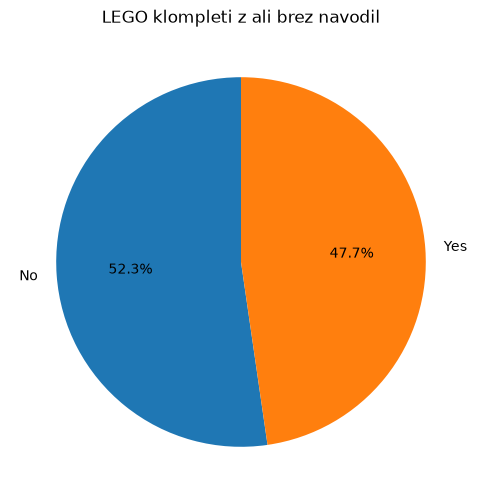

In [55]:
prestej = seti.navodila.value_counts()

plt.figure(figsize=(6,6))
plt.pie(prestej, labels=prestej.index, autopct='%1.1f%%', startangle=90)
plt.title("LEGO klompleti z ali brez navodil")
plt.show()

Morda je res zaskrbljujoče, da več kot polovica kompletov nima navodil, a dejstvo, da lahko vsa navodila za sestavljanje poiščemo na spletu, nekoliko omili zgornji prikaz. Morda pa so se pri podjetju Lego zavzeli za večjo skrb nad okoljem in zato ne tiskajo toliko navodil. Morda bi bilo smiselno pogledati tudi časovni prikaz izdaje kompletov tekom leta 2025 in ali imajo navodila ali ne.

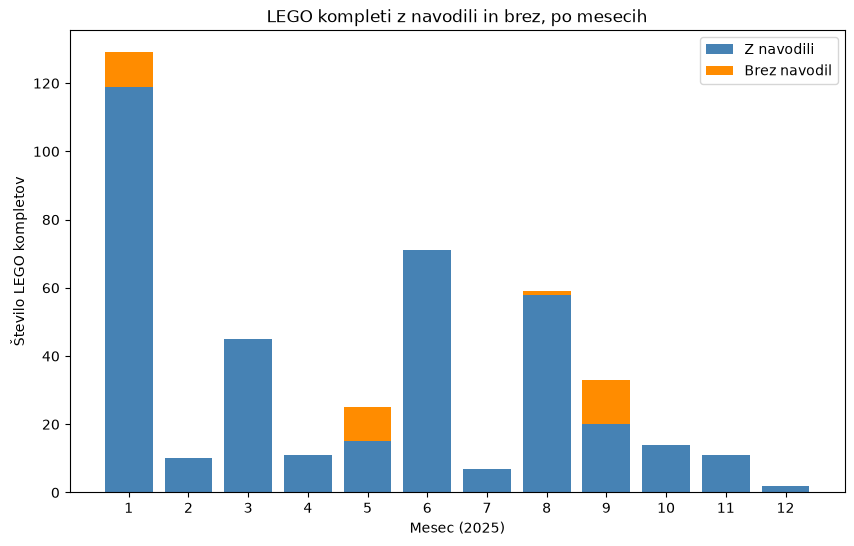

In [56]:
najboljsi['datum_izida'] = pd.to_datetime(najboljsi.datum_izida)
najboljsi['month'] = najboljsi.datum_izida.dt.month

monthly_counts = najboljsi.groupby(['month', 'navodila']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
plt.bar(monthly_counts.index, monthly_counts['Yes'], color='steelblue', label='Z navodili')
plt.bar(monthly_counts.index, monthly_counts['No'], bottom=monthly_counts['Yes'], color='darkorange', label='Brez navodil')

plt.xlabel("Mesec (2025)")
plt.ylabel("Število LEGO kompletov")
plt.title("LEGO kompleti z navodili in brez, po mesecih")
plt.xticks(range(1,13))
plt.legend()
plt.show()

Na zgornjem grafu je videti, kot da se navodila tiskajo le trikrat letno. Šalo na stran. Po podrobnem pregledu CSV datoteke lahko vidimo, da veliko kompletov sploh nima podatka o izdaji, tako da graf nima kakega večjega pomena 

## Najpogostejša tema
Vsi poznamo serijo LEGO izdelkov _City_ ali pa _Technic_, zadnje čase pa je vedno bolj popularna tudi _Flowers_ ali pa _Architecture_. Ampak katera pa je bila najbolj popularna v lanskem letu? 

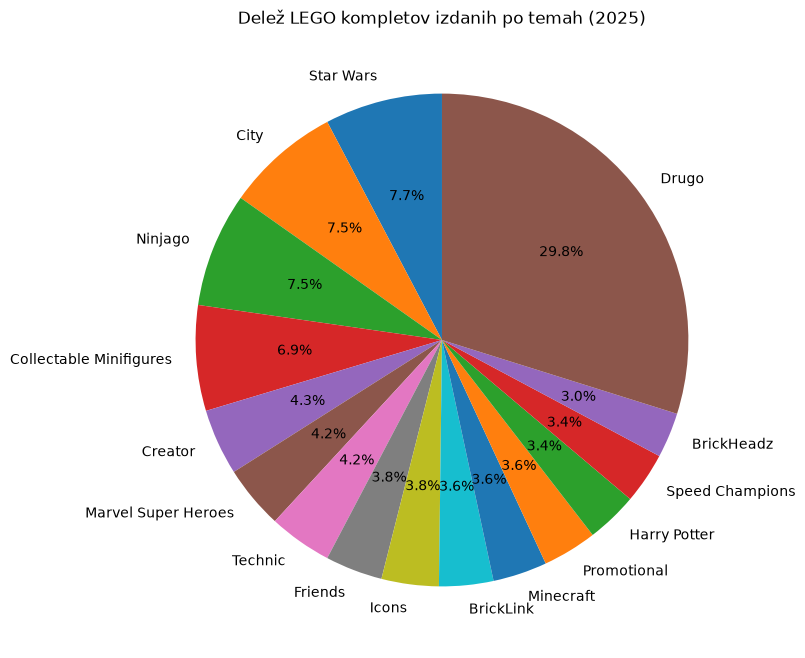

In [57]:
theme_counts = najboljsi.tema.value_counts()

top_n = 15
top_themes = theme_counts[:top_n]
other = theme_counts[top_n:].sum()

final_counts = top_themes.copy()
final_counts['Drugo'] = other

plt.figure(figsize=(8,8))
plt.pie(final_counts, labels=final_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Delež LEGO kompletov izdanih po temah (2025)")
plt.show()

Ker je vseh tem preveč, sem v diagram dodala najpogostejših 15, ostale pa združila v del "drugo". Pod "drugo" tako sodijo _Architecture, Animal crossing, Art, Books, Botanical_ in ostali. Zdaj pa poglejmo katera tema je najbolje ocenjena.

In [58]:
import seaborn as sns

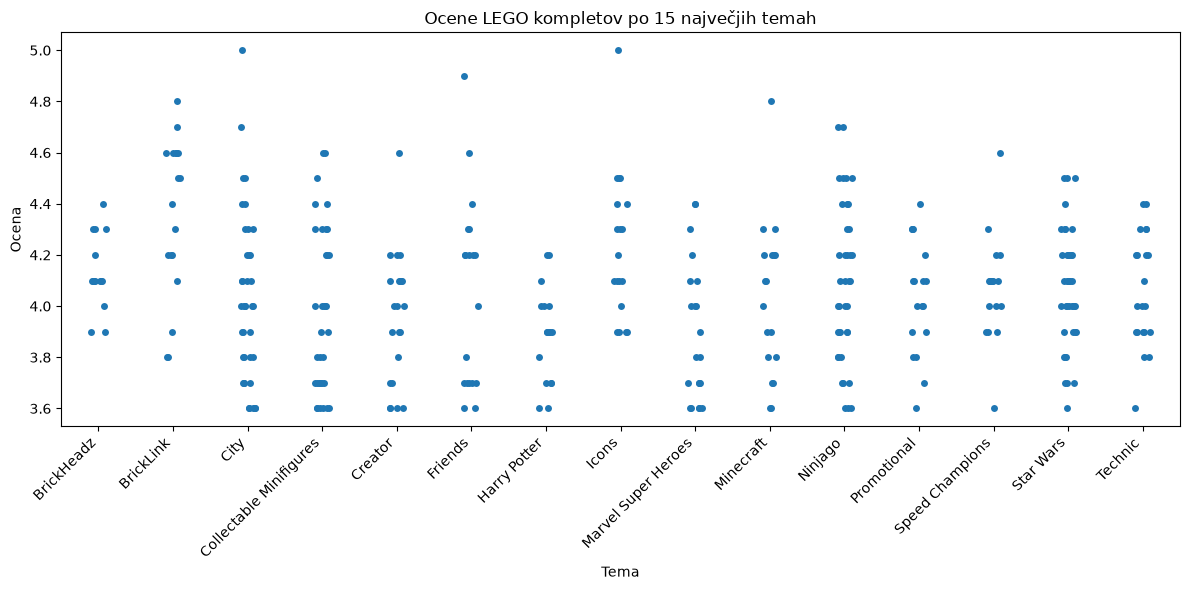

In [59]:
top_15_themes = najboljsi.tema.value_counts().head(15).index

filtered = najboljsi[najboljsi.tema.isin(top_15_themes)]

plt.figure(figsize=(12,6))
sns.stripplot(data=filtered, x='tema', y='ocena', jitter=True)
plt.xticks(rotation=45, ha='right')
plt.title("Ocene LEGO kompletov po 15 največjih temah")
plt.xlabel("Tema")
plt.ylabel("Ocena")
plt.tight_layout()
plt.show()

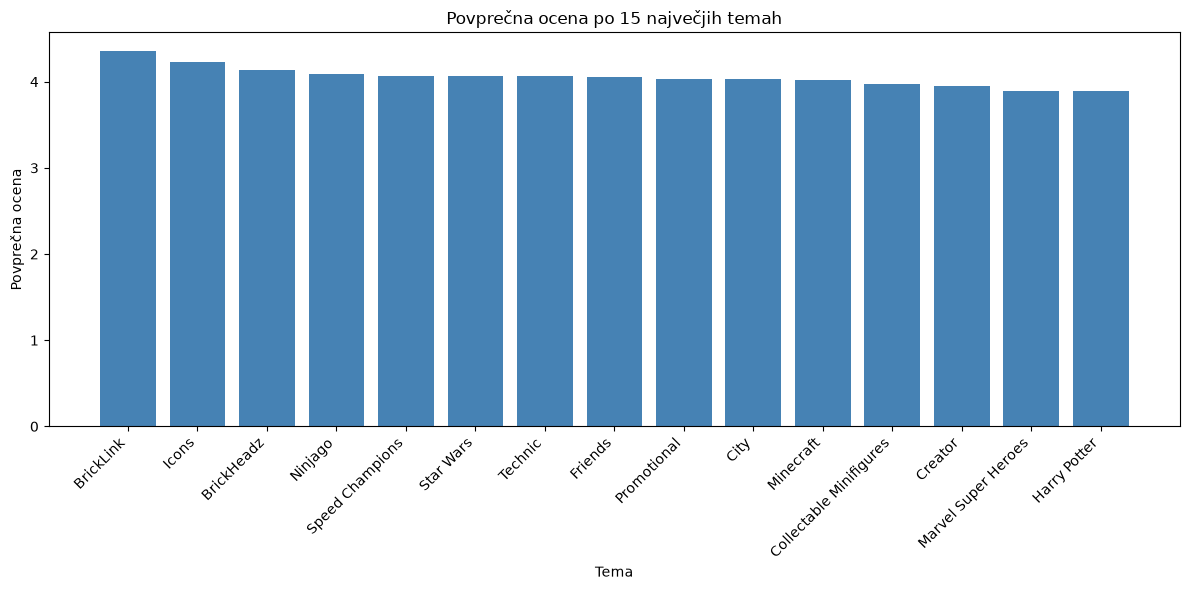

In [60]:
avg_rating = filtered.groupby('tema')['ocena'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(avg_rating.index, avg_rating.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Povprečna ocena po 15 največjih temah")
plt.xlabel("Tema")
plt.ylabel("Povprečna ocena")
plt.tight_layout()
plt.show()

Najpopularnejša je tako _LEGO BrickLink_, a so vse teme zelo tesno skupaj. Poglejmo še, kako so LEGO kocke izhajale tekom lanskega leta.

Index(['Star Wars', 'City', 'Ninjago', 'Collectable Minifigures', 'Creator'], dtype='str', name='tema')


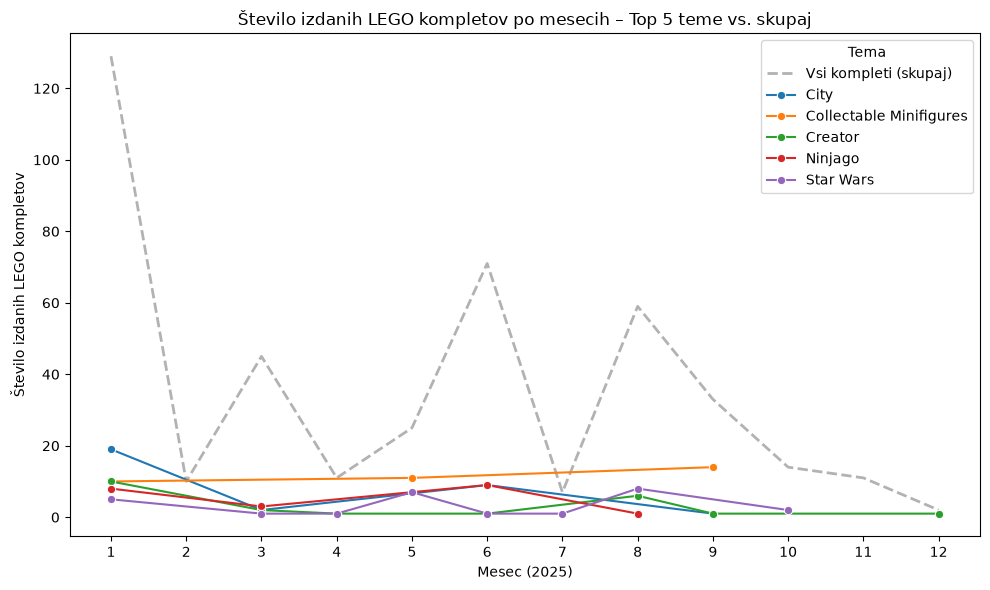

In [61]:
najboljsi.datum_izida = pd.to_datetime(najboljsi.datum_izida)
najboljsi['month'] = najboljsi.datum_izida.dt.month

top_5_themes = najboljsi.tema.value_counts().head(5).index
print(top_5_themes)

filtered = najboljsi[najboljsi.tema.isin(top_5_themes)]

monthly_theme_counts = filtered.groupby(['month', 'tema']).size().reset_index(name='count')

monthly_total = najboljsi.groupby('month').size().reset_index(name='count')

plt.figure(figsize=(10,6))

plt.plot(monthly_total['month'], monthly_total['count'], 
         color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Vsi kompleti (skupaj)')

sns.lineplot(data=monthly_theme_counts, x='month', y='count', hue='tema', marker='o')

plt.xlabel("Mesec (2025)")
plt.ylabel("Število izdanih LEGO kompletov")
plt.title("Število izdanih LEGO kompletov po mesecih – Top 5 teme vs. skupaj")
plt.xticks(range(1,13))
plt.legend(title='Tema')
plt.tight_layout()
plt.show()

Preseneča me, da je daleč največ LEGO kock izšlo v začetku leta, nato pa so še trije vrhovi tekom celotnega leta. Morda je tudi zanimiv podatek, da so zadnji _LEGO Ninjago_ izdali že avgusta, _LEGO City_ in _LEGO Collectable Minifigures_ pa mesec pozneje. Vidimo, da so med najštevilčnejšimi temami zgolj _LEGO Creator_ izdajali še do konca leta. Poglejmo si še razporeditev izdaje LEGO kompletov tekom januarja 2025.

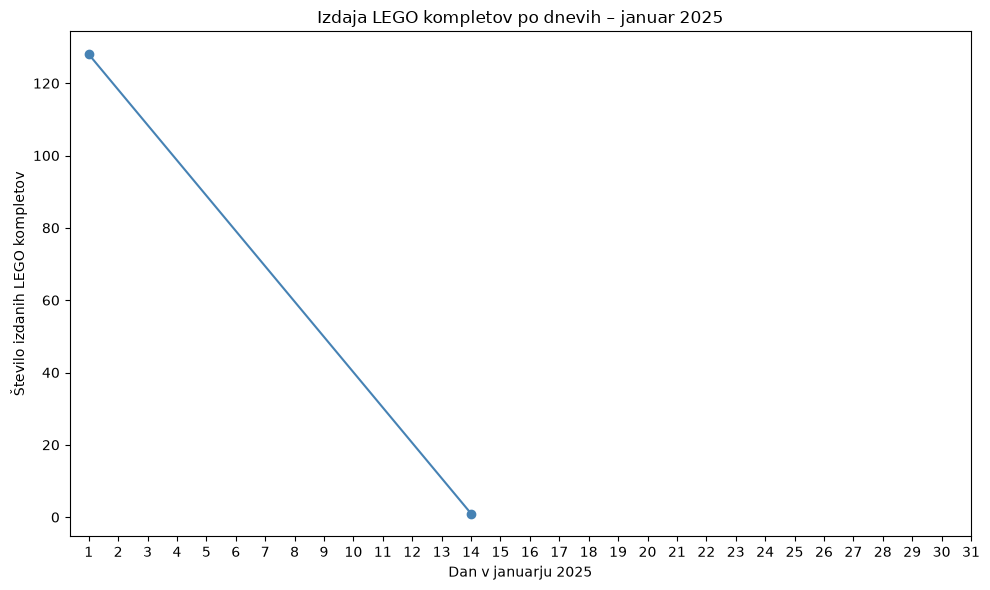

In [62]:
januar = najboljsi[(najboljsi.datum_izida.dt.year == 2025) & (najboljsi.datum_izida.dt.month == 1)]

daily_counts = januar.groupby(najboljsi.datum_izida.dt.day).size()

plt.figure(figsize=(10,6))
plt.plot(daily_counts.index, daily_counts.values, marker='o', color='steelblue')

plt.xlabel("Dan v januarju 2025")
plt.ylabel("Število izdanih LEGO kompletov")
plt.title("Izdaja LEGO kompletov po dnevih – januar 2025")
plt.xticks(range(1,32))
plt.tight_layout()
plt.show()

Vidimo, da je večina kompletov izšlo 1. januarja, en komplet pa je izšel 14. januarja. Ali je ta stil prvega v mesecu in sredina meseca značilna tudi za vse ostale mesece?

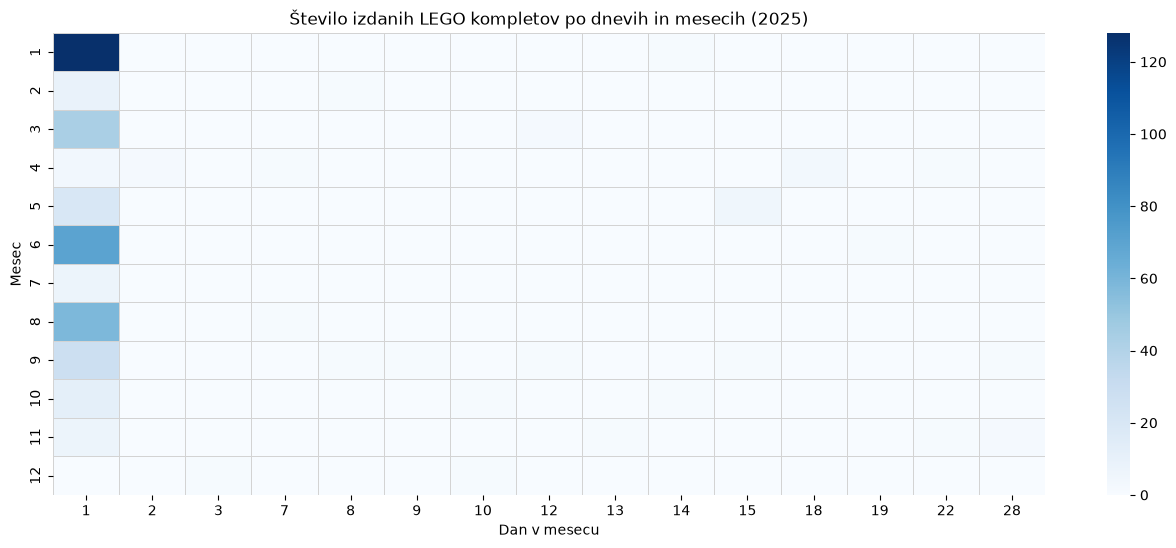

In [63]:
podatki_2025 = najboljsi[najboljsi.datum_izida.dt.year == 2025].copy()

podatki_2025['month'] = podatki_2025.datum_izida.dt.month
podatki_2025['day'] = podatki_2025.datum_izida.dt.day

pivot = podatki_2025.groupby(['month', 'day']).size().unstack(fill_value=0)

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap='Blues', linewidths=0.5, linecolor='lightgray')
plt.xlabel("Dan v mesecu")
plt.ylabel("Mesec")
plt.title("Število izdanih LEGO kompletov po dnevih in mesecih (2025)")
plt.show()

Res vidimo, da so skoraj vsi LEGO kompleti izšli prvi dan v mesecu, meseci z največjim izidom pa so januar, junij in avgust.

## Število koščkov
Poleg podatkov, ki smo jih večinoma že obdelali bi bilo zanimivo pogledati tudi kateri kompleti imajo več koščkov in ali obstaja kakšna povezava med številom koščkov in oceno.

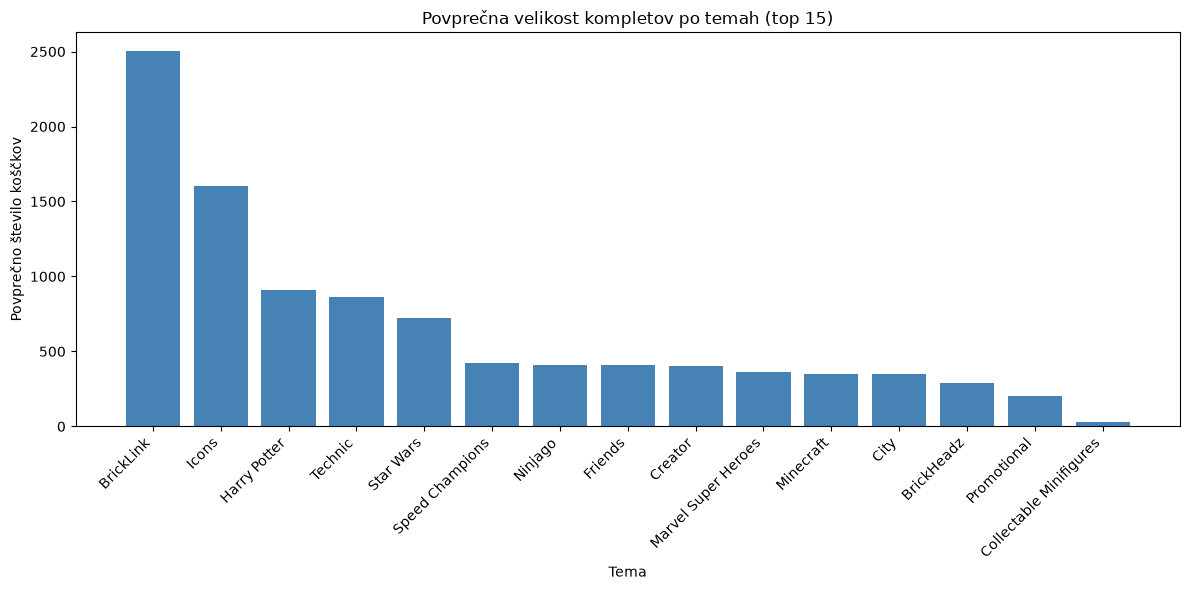

In [64]:
filtered = najboljsi[najboljsi.tema.isin(top_15_themes)]

avg_pieces_theme = filtered.groupby('tema')['kosi'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(avg_pieces_theme.index, avg_pieces_theme.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Tema")
plt.ylabel("Povprečno število koščkov")
plt.title("Povprečna velikost kompletov po temah (top 15)")
plt.tight_layout()
plt.show()

Zgornji graf me zelo preseneča, saj sem mislila, da bosta _LEGO Technic_ in _LEGO Star Wars_ bolj v ospredju. Ko sem malo bolj raziskala po internetu kakšni so kompleti _LEGO BrickLink_ sem ugotovila, da so ti bolj obširni in večinoma namenjeni starejšim, torej imajo spodnjo omejitev 18 let. Za razliko od _LEGO Technic_ in _LEGO Star Wars_, ki sta morda res namenjena tudi nekoliko mlajšim. Poglejmo še boljšo razporeditev koščkov znotraj tem. Torej ali ima _LEGO BrickLink_ res dosledno večje komplete ali zgolj nekaj večjih, ki mu dvignejo povprečje?

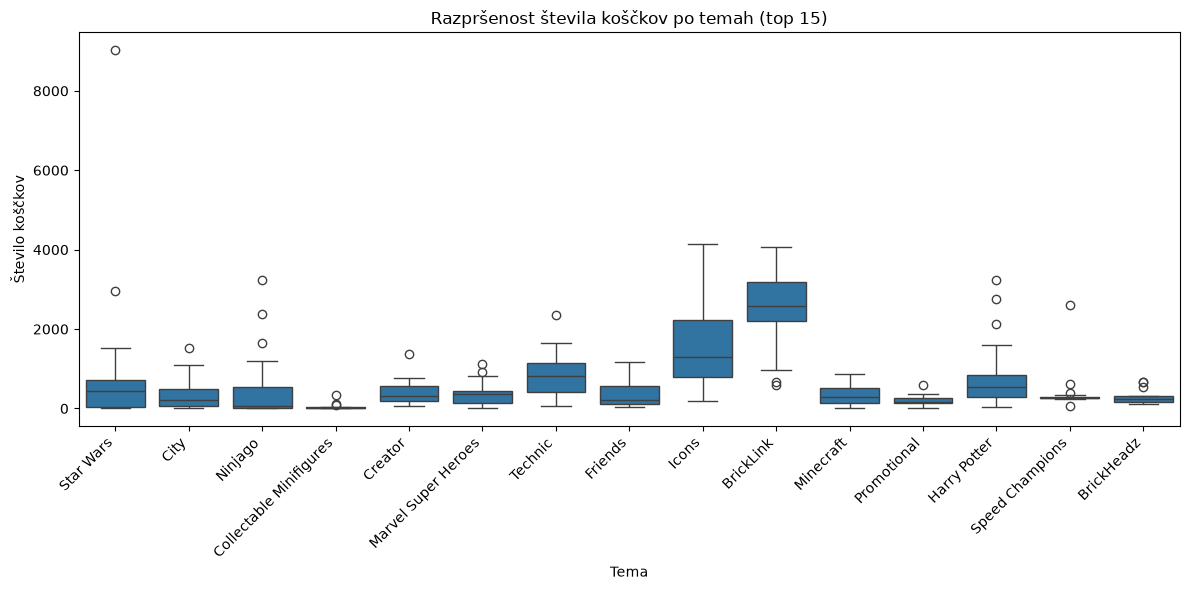

In [65]:
plt.figure(figsize=(12,6))
sns.boxplot(data=filtered, x='tema', y='kosi', order=top_15_themes)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Tema")
plt.ylabel("Število koščkov")
plt.title("Razpršenost števila koščkov po temah (top 15)")
plt.tight_layout()
plt.show()

Presenetljivo ima _LEGO Star Wars_ največji komplet, a hkrati tudi kar nekaj manjših, zato ima skupno povprečje nekoliko manjše. Poglejmo še, ali velikost res vpliva na kakovost, torej ali ljudje res bolj cenijo večje in zahtevnejše komplete?

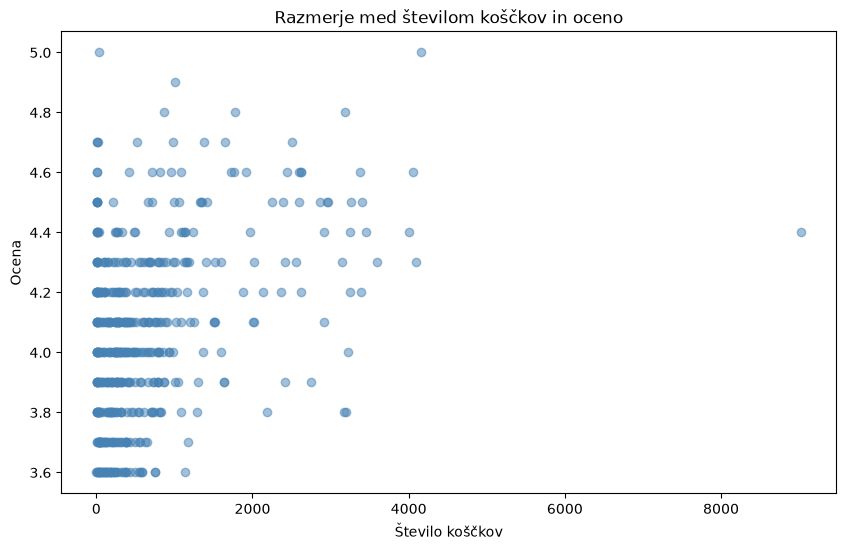

In [66]:
plt.figure(figsize=(10,6))
plt.scatter(najboljsi['kosi'], najboljsi['ocena'], alpha=0.5, color='steelblue')
plt.xlabel("Število koščkov")
plt.ylabel("Ocena")
plt.title("Razmerje med številom koščkov in oceno")
plt.show()

Iz zgornjega grafa lahko razberemo to, da so majhni do srednje veliki kompleti najpogostejši in njihova ocena ni odvisna od velikosti. Imajo tako nizke kot tudi visoke ocene. Kljub temu pa iz grafa ni razvidne neke povezave med velikostjo kompleta in njegovo oceno. Zelo pa izstopa osamelec v desnem delu grafa pri oceni približno 4.4 in številu koščkov okoli 9000. Glede na prejšnji graf je to največji LEGO komplet nasploh in prihaja iz kategorije _LEGO Star Wars_. Vredno bi bilo pogledati še podatke največjih kompletov. 

In [67]:
najboljsi.sort_values('kosi', ascending=False).head(7)

,ime,tema,kosi,ocena,stevilo_ocen,stevilo_recenzij,velikost_modela,navodila,datum_izida,month
stevilka,,,,,,,,,,
75419-1,Death Star,Star Wars,9023.0,4.4,63,0,79 x 70 x 27 cm,Yes,2025-10-01,10.0
10366-1,Tropical Aquarium,Icons,4154.0,5.0,4,1,52 x 36 x 28 cm,Yes,2025-11-13,11.0
21356-1,River Steamboat,Ideas,4090.0,4.3,22,0,40 x 69 x 15 cm,Yes,2025-04-07,4.0
910049-1,Adventure in Transylvania,BrickLink,4056.0,4.6,57,0,NaN,Yes,2025-11-01,11.0
910053-1,The Thieves of Tortuga,BrickLink,4002.0,4.4,58,1,NaN,Yes,2025-11-01,11.0
10356-1,Star Trek: U.S.S. Enterprise NCC-1701-D,Icons,3600.0,4.3,68,1,48 x 27 x 60 cm,Yes,2025-11-28,11.0
21063-1,Neuschwanstein Castle,Architecture,3455.0,4.4,40,0,31 x 46 x 20 cm,Yes,2025-08-01,8.0


Poglejmo še točnejši histogram za določitev manjših in srednje velikih kompletov, ki smo jih opazili v diagramu z ocenami.

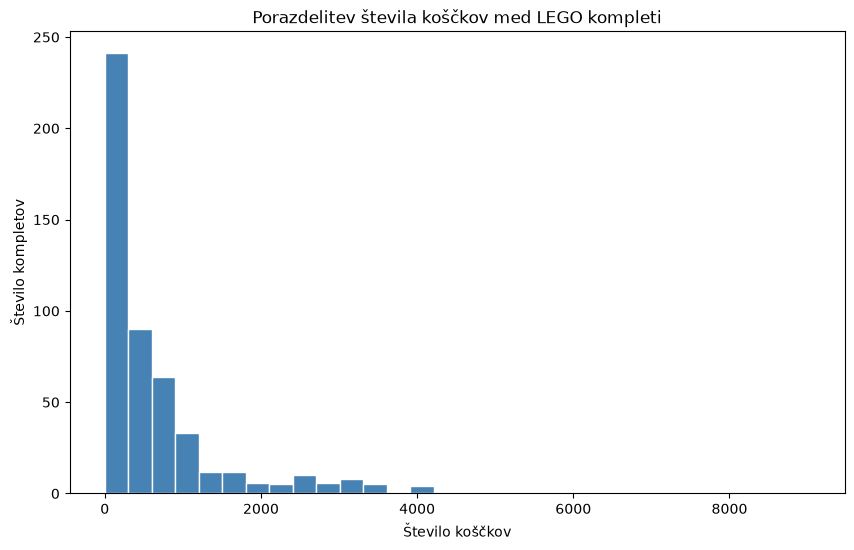

In [68]:
plt.figure(figsize=(10,6))
plt.hist(najboljsi['kosi'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.xlabel("Število koščkov")
plt.ylabel("Število kompletov")
plt.title("Porazdelitev števila koščkov med LEGO kompleti")
plt.show()

Sedaj pa si poglejmo še gostoto gradnje. Torej število koščkov glede na celotno, fizično velikost sestavljenega modela oziroma kompleta. S tem bomo videli ali imajo večji kompleti tudi sorazmerno več koščkov, ali so nekateri modeli "bolj votli" (manj gosto sestavljeni). 

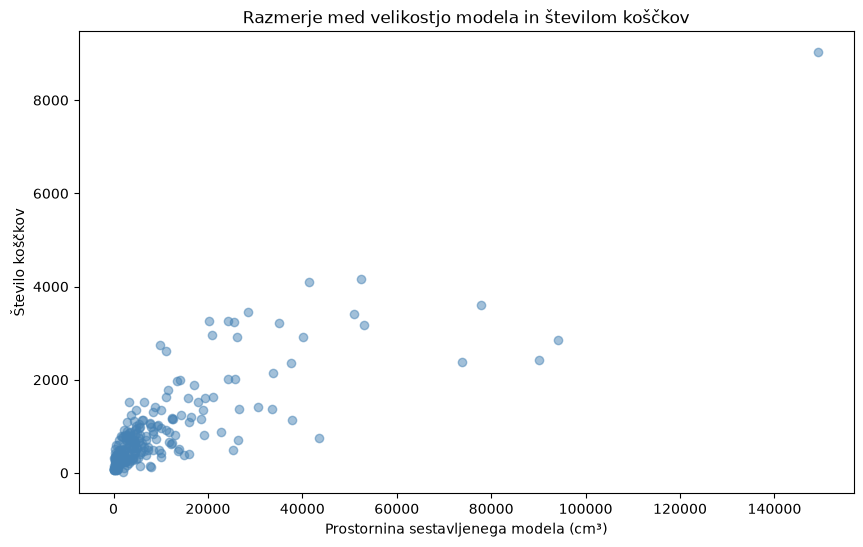

In [69]:
import re

def izracunaj_volumen(velikost):
    if pd.isna(velikost):
        return None
    stevila = re.findall(r'\d+\.?\d*', velikost)
    if len(stevila) == 3:
        d, s, v = map(float, stevila)
        return d * s * v
    return None

najboljsi['volumen'] = najboljsi.velikost_modela.apply(izracunaj_volumen)

plt.figure(figsize=(10,6))
plt.scatter(najboljsi['volumen'], najboljsi['kosi'], alpha=0.5, color='steelblue')
plt.xlabel("Prostornina sestavljenega modela (cm³)")
plt.ylabel("Število koščkov")
plt.title("Razmerje med velikostjo modela in številom koščkov")
plt.show()

Po pričakovanjih vidimo, da večji ko je model, več koščkov ima. A povezava ni popolnoma linearna, saj pike ne ležijo na eni ravni črti. Kljub temu pa izstopajo nekateri veliki modeli, ki imajo presenetljivo malo koščkov (desna stran grafa). Po pričakovanjih ima največje razmerje že znan osamelec _LEGO Star Wars Death Star_. Opazimo lahko tudi najbolj votel komplet s prostornino nekaj čez 40.000 $m^3$ in cca. 700 koščki. Poiščimo ta komplet s pomočjo tabele.

In [70]:
najboljsi['gostota'] = najboljsi['kosi'] / najboljsi['volumen']

najboljsi.sort_values('gostota').head(7)[['ime', 'tema', 'kosi', 'volumen', 'gostota']]

,ime,tema,kosi,volumen,gostota
stevilka,,,,,
10442-1,Wild Animal Families: Penguins & Lions,Duplo,10.0,2002.0,0.004995
71829-1,Lloyd's Green Forest Dragon,Ninjago,128.0,7920.0,0.016162
60469-1,Central Train Station,City,752.0,43560.0,0.017264
5009609-1,Captain Jack Sparrow's Compass,Promotional,151.0,7800.0,0.019359
10363-1,Leonardo da Vinci's Flying Machine,Icons,493.0,25375.0,0.019429
60465-1,Air Ambulance,City,403.0,15984.0,0.025213
11200-1,Spidey and Gobby's Raptor Battle at Tree House HQ,Marvel Super Heroes,143.0,5520.0,0.025906


Najbolj votel komplet ne preseneča, saj je _LEGO Duplo_ zasnovan za mlajše otroke in ima zato manj koščkov, ki pa so veliko večji od klasičnih. Bolj zanimiv je tretji podatek po vrsti, _Central Train Station_. Predvidevam, da ima komplet votlo stavbo ali vlak ali pa kako streho, ki poveča prostornino. Ta tabela lepo dopolnjuje prejšnji graf — potrjuje, da nizka gostota ni nujno povezana z eno samo temo ali starostno skupino, ampak se pojavlja iz različnih razlogov: bodisi ker je izdelek namenjen malčkom (Duplo), bodisi ker gre za velike, votlo zasnovane modele stavb/vozil, kjer je vizualna velikost pomembnejša od količine detajlov.